#  Clasificación de Tickets Cerrados de Incidentes Bancarios


## 1. Carga de Librerías y Configuración Inicial

In [52]:
# ── Librería estándar ─────────────────────────────────────────────────────────
import os
import re
import unicodedata
import warnings
from collections import Counter

# ── Datos y visualización ─────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# ── Procesamiento de texto ────────────────────────────────────────────────────
import nltk
from nltk.corpus import stopwords

# ── Estadística y matrices dispersas ─────────────────────────────────────────
from scipy.stats import f_oneway
from scipy.sparse import vstack

# ── Scikit-learn: features y preprocesamiento ────────────────────────────────
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

# ── Scikit-learn: modelos ─────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

# ── Scikit-learn: selección de modelos y métricas ────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    f1_score, precision_score, recall_score
)

# ── Imbalanced-learn ─────────────────────────────────────────────────────────
from imblearn.over_sampling import RandomOverSampler

warnings.filterwarnings('ignore')

# ── Configuración de gráficos ─────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-darkgrid')
sns.set(rc={'figure.figsize': (10, 6)})


## 2. Carga y Exploración Inicial de Datos

In [53]:
# Cargar el archivo CSV
# Ruta relativa desde Analisis/ hacia Data/ (un nivel arriba)
ruta_csv = os.path.join(os.path.dirname(os.getcwd()), 'Data', 'IncidentesCategorizados-Final-Final-Corregido.csv')
print('Directorio actual:', os.getcwd())
print('Ruta CSV:', ruta_csv)

# Intenta cargar el archivo
try:
    df = pd.read_csv(ruta_csv, sep=',', encoding='latin-1')
except FileNotFoundError as e:
    print('No se encontró el archivo. Verifica la ruta y ubicación.')
    raise e

# Mostrar primeras filas y resumen
print('Dimensiones:', df.shape)
df.head()


Directorio actual: c:\Users\paomaribel\Documents\GitHub\Asignador\Analisis
Ruta CSV: c:\Users\paomaribel\Documents\GitHub\Asignador\Data\IncidentesCategorizados-Final-Final-Corregido.csv
Dimensiones: (7353, 30)


,number,state,sys_created_on,category,u_subcategory,u_subcategory_2,contact_type,business_duration,cmdb_ci_business_app,cmdb_ci,...,location.cmn_location_type,assignment_group,assigned_to,description,comments_and_work_notes,resolved_at,close_notes,u_categoria_error,u_subcategoria_error,Categoría
0,INC0755414,Nuevo,19/02/2026 16:30:59,Aplicaciones,Apertura Incidentes de Aplicaciones,Incidentes otras Aplicaciones,Self Service,0.0,Bancs,NaN,...,Agencia,TEC_TCS_N1_RYR_APLICACIONES,NANCY CECILIA NASIMBA CHALCO,segun ticket ingresado RITM0800991 me sugiere...,NaN,NaN,NaN,NaN,NaN,Activos
1,INC0754016,Nuevo,18/02/2026 23:00:43,Aplicaciones,Apertura Incidentes de Aplicaciones,Incidentes otras Aplicaciones,Self Service,0.0,Bancs,NaN,...,Edificio/Estructura,TEC_TCS_N1_RYR_APLICACIONES,LUISA VERONICA MORENO LEMA,CON FECHA 22 DE ENERO 2026 LAS OPERACIONES 800...,NaN,NaN,NaN,NaN,NaN,Activos
2,INC0754538,Nuevo,19/02/2026 09:55:17,Aplicaciones,Apertura Incidentes de Aplicaciones,Incidentes BANCs/BancsLinks Producción,Self Service,0.0,Bancs,NaN,...,Agencia,TEC_TCS_N1_RYR_APLICACIONES,LUISA VERONICA MORENO LEMA,"Favor su apoyo, revisando el abono al capital,...",NaN,NaN,NaN,NaN,NaN,Activos
3,INC0753295,Nuevo,18/02/2026 14:30:54,Aplicaciones,Apertura Incidentes de Aplicaciones,Incidentes otras Aplicaciones,Self Service,0.0,Bancs,NaN,...,Agencia,TEC_TCS_N1_RYR_APLICACIONES,LUISA VERONICA MORENO LEMA,por favor su ayuda con la regularización para ...,18/02/2026 17:35:05 - JOAO CRISTOFFER PEREZ PA...,NaN,NaN,NaN,NaN,Activos
4,INC0756601,Nuevo,20/02/2026 10:46:17,Aplicaciones,Apertura Incidentes de Aplicaciones,Incidentes BANCs/BancsLinks Producción,Self Service,0.0,Bancs,NaN,...,Agencia,TEC_TCS_N1_RYR_APLICACIONES,LEONELA JACKELINE DELGADO MENDIETA,su gentil ayuda con el siguiente caso la clien...,NaN,NaN,NaN,NaN,NaN,NaN


In [54]:
# Tipos de datos y valores nulos
df.info()
df.isnull().sum().sort_values(ascending=False).head(15)

<class 'pandas.DataFrame'>
RangeIndex: 7353 entries, 0 to 7352
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   number                      7353 non-null   str    
 1   state                       7352 non-null   str    
 2   sys_created_on              7352 non-null   str    
 3   category                    7352 non-null   str    
 4   u_subcategory               7352 non-null   str    
 5   u_subcategory_2             7352 non-null   str    
 6   contact_type                7352 non-null   str    
 7   business_duration           7352 non-null   float64
 8   cmdb_ci_business_app        4792 non-null   str    
 9   cmdb_ci                     2329 non-null   str    
 10  short_description           7352 non-null   str    
 11  priority                    7352 non-null   str    
 12  severity                    7352 non-null   str    
 13  caller_id                   7352 non-null   

cmdb_ci                       5024
cmdb_ci_business_app          2561
comments_and_work_notes       1454
u_subcategoria_error           642
u_categoria_error              640
location.cmn_location_type     588
location                       588
Categoría                      315
u_affected_user.department     117
resolved_at                     28
close_notes                     27
assigned_to                      8
description                      6
u_affected_user                  4
u_affected_user.title            4
dtype: int64

In [55]:
# Exploración rápida de variables informativas
print('\nPorcentaje de valores nulos por columna:')
print((df.isnull().mean()*100).sort_values(ascending=False))
print('\nNúmero de valores únicos por columna:')
print(df.nunique().sort_values(ascending=False))

# Sugerencia de variables informativas (no ID, no columnas vacías o con un solo valor)
columnas_informativas = [col for col in df.columns if df[col].nunique()>1 and df[col].nunique()<df.shape[0]*0.9 and not col.lower().startswith('id')]
print('\nColumnas potencialmente informativas:')
print(columnas_informativas)



Porcentaje de valores nulos por columna:
cmdb_ci                       68.325853
cmdb_ci_business_app          34.829321
comments_and_work_notes       19.774242
u_subcategoria_error           8.731130
u_categoria_error              8.703930
location.cmn_location_type     7.996736
location                       7.996736
Categoría                      4.283966
u_affected_user.department     1.591187
resolved_at                    0.380797
close_notes                    0.367197
assigned_to                    0.108799
description                    0.081599
u_affected_user                0.054400
u_affected_user.title          0.054400
u_affected_user.company        0.054400
priority                       0.013600
severity                       0.013600
sys_created_on                 0.013600
caller_id                      0.013600
u_subcategory_2                0.013600
short_description              0.013600
contact_type                   0.013600
state                          0.01360

## 3. Limpieza y Preprocesamiento de Datos

## 3.1 Columna Clasificación

In [56]:
# Cambiar el nombre de la columna 'Categoria' por 'Clasificación'
df = df.rename(columns={"Categoría": "Clasificación"})

In [57]:
# Mostrar la distribución de clases (conteo de tickets por clasificación)
conteo_clases = df['Clasificación'].value_counts(dropna=False)
print(conteo_clases)

Clasificación
0                         3391
BancsLink                  722
Activos                    545
Cuentas                    429
Inversiones                366
Pendiente                  328
NaN                        315
Contabilidad               220
Formas numeradas           169
Chequeras                  152
Cheques                    146
SISREP                     134
Reportes Batch              79
Estados de cuenta           64
Garantías                   51
No productivo               45
Retenciones Judiciales      39
Clientes                    33
Firmas autorizadas          29
Incidencias                 17
Cartola                     15
No aplica                   14
Sobregiros                  11
Formas Numeradas            11
Firmas Autorizadas           9
CNBs                         6
MT940                        4
Trickle Feed                 4
Cuentas                      2
CC-Cancelación batch         2
CC-Evento/alerta             1
Name: count, dtype: int64

In [58]:
# Revisar valores únicos y nulos en 'Clasificación'
if 'Clasificación' in df.columns:
    print('Valores únicos en Clasificación:', df['Clasificación'].unique())
    print('Valores nulos en Clasificación:', df['Clasificación'].isnull().sum())
else:
    print("La columna 'Clasificación' no está presente en el DataFrame.")

Valores únicos en Clasificación: <StringArray>
[               'Activos',                      nan,      'Estados de cuenta',
             'Sobregiros',                'Cuentas',         'Reportes Batch',
       'Formas numeradas',                      '0',              'Chequeras',
                'Cheques',                 'SISREP',              'BancsLink',
            'Inversiones',           'Contabilidad',              'Pendiente',
                  'MT940',              'No aplica',          'No productivo',
              'Garantías',            'Incidencias',               'Clientes',
       'Formas Numeradas',     'Firmas Autorizadas', 'Retenciones Judiciales',
               'Cuentas ',           'Trickle Feed',     'Firmas autorizadas',
                'Cartola',                   'CNBs',   'CC-Cancelación batch',
       'CC-Evento/alerta']
Length: 31, dtype: str
Valores nulos en Clasificación: 315


In [59]:
# Normalización de valores en la columna 'Clasificación'
def normalizar_texto(texto):
    if pd.isnull(texto):
        return "sin_clasificar"
    texto = str(texto).strip().lower()
    texto = unicodedata.normalize('NFKD', texto).encode('ascii', 'ignore').decode('utf-8')
    texto = re.sub(r'\s+', ' ', texto)
    texto = texto.replace('.', '')
    texto = texto.replace('/', '-')
    texto = texto.strip()
    return texto

df['Clasificación'] = df['Clasificación'].apply(normalizar_texto)

# Verifica los valores únicos después de la normalización
# Revisar valores únicos y nulos en 'Clasificación'
if 'Clasificación' in df.columns:
    print('Valores únicos en Clasificación:', df['Clasificación'].unique())
    print('Valores nulos en Clasificación:', df['Clasificación'].isnull().sum())
else:
    print("La columna 'Clasificación' no está presente en el DataFrame.")


Valores únicos en Clasificación: <StringArray>
[               'activos',         'sin_clasificar',      'estados de cuenta',
             'sobregiros',                'cuentas',         'reportes batch',
       'formas numeradas',                      '0',              'chequeras',
                'cheques',                 'sisrep',              'bancslink',
            'inversiones',           'contabilidad',              'pendiente',
                  'mt940',              'no aplica',          'no productivo',
              'garantias',            'incidencias',               'clientes',
     'firmas autorizadas', 'retenciones judiciales',           'trickle feed',
                'cartola',                   'cnbs',   'cc-cancelacion batch',
       'cc-evento-alerta']
Length: 28, dtype: str
Valores nulos en Clasificación: 0


In [60]:
# 1. Agrupar valores en plural y singular en la columna 'Clasificación'
agrupaciones_plural = {
    'cheques': 'cheque',
    'cuentas': 'cuenta',
    'activos': 'activo',
    'garantias': 'garantia',
    'inversiones': 'inversion',
    'sobregiros': 'sobregiro',
    'usuarios': 'usuario',
    'procesos': 'proceso',
    'clientes': 'cliente',
    'reportes online': 'reporte online',
    'reportes batch': 'reporte batch',
    'formas numeradas': 'forma numerada',
    # Agregar más se detectan otros casos
}
df['Clasificación'] = df['Clasificación'].replace(agrupaciones_plural)

In [61]:
# Reemplazar valores sin clasificar y pendientes → sin_clasificar
df['Clasificación'] = df['Clasificación'].replace(
    ['0', 0, None, np.nan, 'no aplica', 'pendiente'],
    'sin_clasificar'
)

# Eliminar filas con clases que tienen muy pocos ejemplos para entrenar (< 3)
clases_a_eliminar = ['cc-cancelacion batch', 'cc-evento-alerta']
filas_antes = len(df)
df = df[~df['Clasificación'].isin(clases_a_eliminar)].reset_index(drop=True)
print(f"Filas eliminadas: {filas_antes - len(df)}  ({clases_a_eliminar})")
print(f"Total filas restantes: {len(df)}")


Filas eliminadas: 3  (['cc-cancelacion batch', 'cc-evento-alerta'])
Total filas restantes: 7350


In [62]:
# Verifica los valores únicos después de la normalización
print(df['Clasificación'].unique())


<StringArray>
[                'activo',         'sin_clasificar',      'estados de cuenta',
              'sobregiro',                 'cuenta',          'reporte batch',
         'forma numerada',              'chequeras',                 'cheque',
                 'sisrep',              'bancslink',              'inversion',
           'contabilidad',                  'mt940',          'no productivo',
               'garantia',            'incidencias',                'cliente',
     'firmas autorizadas', 'retenciones judiciales',           'trickle feed',
                'cartola',                   'cnbs']
Length: 23, dtype: str


In [63]:
# Mostrar la distribución de clases (conteo de tickets por clasificación)
conteo_clases = df['Clasificación'].value_counts(dropna=False)
print(f"Total de clases de Clasificación: {conteo_clases.shape[0]}")
print()
print(conteo_clases)


Total de clases de Clasificación: 23

Clasificación
sin_clasificar            4048
bancslink                  722
activo                     545
cuenta                     431
inversion                  366
contabilidad               220
forma numerada             180
chequeras                  152
cheque                     146
sisrep                     134
reporte batch               79
estados de cuenta           64
garantia                    51
no productivo               45
retenciones judiciales      39
firmas autorizadas          38
cliente                     33
incidencias                 17
cartola                     15
sobregiro                   11
cnbs                         6
mt940                        4
trickle feed                 4
Name: count, dtype: int64


In [64]:
# Verificar duplicados en el DataFrame
duplicados = df[df.duplicated()]
print(f"Número de filas duplicadas: {duplicados.shape[0]}")
if not duplicados.empty:
    display(duplicados.head())
else:
    print("No se encontraron filas duplicadas.")

Número de filas duplicadas: 0
No se encontraron filas duplicadas.


## 3.2 Análisis de tickets en estado 'Cancelado' 


In [65]:
# 1. Ver todos los valores únicos de 'state' para confirmar cómo aparece "Cancelado"
print("Valores únicos en 'state':")
print(df['state'].value_counts(dropna=False))

Valores únicos en 'state':
state
Cerrado       7300
Resuelto        22
Nuevo           11
En proceso      10
Pendiente        6
NaN              1
Name: count, dtype: int64


In [76]:
# 2. Filtrar tickets cancelados (case-insensitive, por si hay variantes de mayúsculas)
mask_cancelado = df['state'].str.strip().str.lower() == 'cerrado'
df_cancelados = df[mask_cancelado].copy()
print(f"\nTotal de tickets: {len(df)}")
print(f"Tickets cerrado9s: {len(df_cancelados)} ({len(df_cancelados)/len(df)*100:.2f}%)")



Total de tickets: 7350
Tickets cerrado9s: 7300 (99.32%)


In [67]:
# 3. Distribución de 'Clasificación' dentro de los cancelados
print("\nDistribución de Clasificación en tickets cancelados:")
print(df_cancelados['Clasificación'].value_counts(dropna=False))


Distribución de Clasificación en tickets cancelados:
Clasificación
sin_clasificar            4007
bancslink                  722
activo                     541
cuenta                     430
inversion                  366
contabilidad               220
forma numerada             180
chequeras                  152
cheque                     146
sisrep                     134
reporte batch               78
estados de cuenta           62
garantia                    51
no productivo               45
retenciones judiciales      39
firmas autorizadas          38
cliente                     33
incidencias                 17
cartola                     15
sobregiro                   10
cnbs                         6
mt940                        4
trickle feed                 4
Name: count, dtype: int64


In [68]:
# 4. Distribución por categoría/subcategoría original
if 'category' in df_cancelados.columns:
    print("\nDistribución por 'category' en tickets cancelados:")
    print(df_cancelados['category'].value_counts(dropna=False))

if 'u_subcategory' in df_cancelados.columns:
    print("\nDistribución por 'u_subcategory' en tickets cancelados:")
    print(df_cancelados['u_subcategory'].value_counts(dropna=False).head(15))


Distribución por 'category' en tickets cancelados:
category
Aplicaciones                  7219
Pedidos de Información          51
Atención Puesto de Trabajo      20
Infraestructura                  4
admon_entorno                    4
Usuarios y Accesos               2
Name: count, dtype: int64

Distribución por 'u_subcategory' en tickets cancelados:
u_subcategory
Apertura Incidentes de Aplicaciones             7188
Apertura Incidentes Pedidos de Informacion        51
Incidentes Servicios TI                           27
Apertura Incidentes Puesto de Trabajo             20
Incidentes en Servicios de Datos y Analítica       4
incidente_no_prod                                  4
Apertura Incidentes de Infraestructura ENP         3
Apertura Incidentes de Usuarios y Accesos          2
Apertura Incidentes de Infraestructura PROD        1
Name: count, dtype: int64


In [69]:
# 5. Comparar cancelados vs no cancelados: ¿cuántos ya estaban "sin_clasificar"?
if 'Clasificación' in df_cancelados.columns:
    pct_sin_clasificar = (df_cancelados['Clasificación'] == 'sin_clasificar').mean() * 100
    print(f"\n% de cancelados que están 'sin_clasificar': {pct_sin_clasificar:.2f}%")


% de cancelados que están 'sin_clasificar': 54.89%


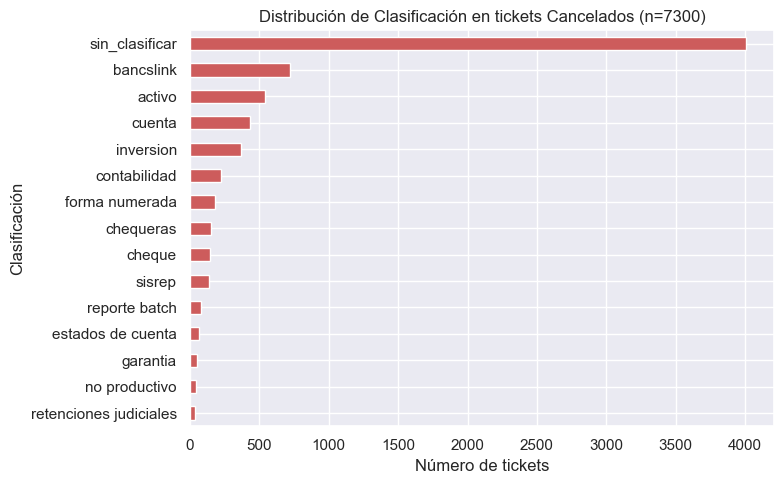

,number,state,short_description,description,Clasificación
49,INC0365775,Cerrado,PAGO DUPLICADO POR CHEQUE CASH,se realizó un pago con cheque por el valor de ...,forma numerada
50,INC0066847,Cerrado,2301: CÓDIGO DE PRIORIDAD DE DESEMBOLSO DEL RE...,NO PERMITE CANCELAR LA OPERACION SE GENERA ERR...,sin_clasificar
51,INC0624816,Cerrado,ERROR AL ACTIVAR UNA CHEQUERA,Favor su ayuda ya que al momento de activar la...,chequeras
52,INC0262112,Cerrado,"NO SE PUEDE ACCEDER AL BANCS , NO SE REFLEJAN ...","NO SE PUEDE ACCEDER AL BANCS , NO SE REFLEJAN ...",sin_clasificar
53,INC0227716,Cerrado,Su ayuda con la revisión de opciones que dispo...,Su ayuda con la revisión de opciones que dispo...,sin_clasificar
54,INC0625505,Cerrado,"No permite recepción FN, cheque de emergencia ...","No permite recepción FN, cheque de emergencia ...",cheque
55,INC0618696,Cerrado,SISREP - ERROR REPETITIVO EN SACRA REPORTE EN ...,URGENTE NO SE PUEDE SACAR REPORTE DE FORMAS NU...,sisrep
56,INC0160414,Cerrado,ERROR EN COMPROBANTE DE AVALUO,BUEN DIA SU APOYO CON EL COMPROBANTE DE AVALUO...,sin_clasificar
57,INC0152338,Cerrado,Error en la cola del bancs BRIO038408213UL,Error en la cola del bancs BRIO038408213UL,sin_clasificar
58,INC0635254,Cerrado,sisrep - su ayuda con la revision de sistema b...,su ayuda con la revision de sistema bancs no p...,sisrep


In [70]:
# 6. Visualización rápida
plt.figure(figsize=(8, 5))
df_cancelados['Clasificación'].value_counts().head(15).plot(kind='barh', color='indianred')
plt.title(f'Distribución de Clasificación en tickets Cancelados (n={len(df_cancelados)})')
plt.xlabel('Número de tickets')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# 7. (Opcional) Vista rápida de ejemplos cancelados
display(df_cancelados[['number', 'state', 'short_description', 'description', 'Clasificación']].head(10))

In [71]:
# Comparar distribución de clases: cancelados-clasificados vs resto del dataset
df_cancelados_clasif = df_cancelados[df_cancelados['Clasificación'] != 'sin_clasificar']
df_resto_clasif = df[~mask_cancelado & (df['Clasificación'] != 'sin_clasificar')]

comparacion = pd.DataFrame({
    'Cancelados (%)': df_cancelados_clasif['Clasificación'].value_counts(normalize=True) * 100,
    'Resto (%)': df_resto_clasif['Clasificación'].value_counts(normalize=True) * 100
}).fillna(0).round(2)

comparacion['Diferencia'] = (comparacion['Cancelados (%)'] - comparacion['Resto (%)']).round(2)
print(comparacion.sort_values('Diferencia', ascending=False))

                        Cancelados (%)  Resto (%)  Diferencia
Clasificación                                                
bancslink                        21.93       0.00       21.93
inversion                        11.11       0.00       11.11
contabilidad                      6.68       0.00        6.68
forma numerada                    5.47       0.00        5.47
chequeras                         4.62       0.00        4.62
cheque                            4.43       0.00        4.43
sisrep                            4.07       0.00        4.07
cuenta                           13.06      11.11        1.95
garantia                          1.55       0.00        1.55
no productivo                     1.37       0.00        1.37
retenciones judiciales            1.18       0.00        1.18
firmas autorizadas                1.15       0.00        1.15
cliente                           1.00       0.00        1.00
incidencias                       0.52       0.00        0.52
cartola 

In [72]:
print(list(df.columns))

['number', 'state', 'sys_created_on', 'category', 'u_subcategory', 'u_subcategory_2', 'contact_type', 'business_duration', 'cmdb_ci_business_app', 'cmdb_ci', 'short_description', 'priority', 'severity', 'caller_id', 'u_affected_user', 'u_affected_user.title', 'u_affected_user.department', 'u_affected_user.company', 'location', 'reopen_count', 'location.cmn_location_type', 'assignment_group', 'assigned_to', 'description', 'comments_and_work_notes', 'resolved_at', 'close_notes', 'u_categoria_error', 'u_subcategoria_error', 'Clasificación']


In [73]:
# Tickets en estado 'Cerrado'
df_cerrados = df[df['state'].str.strip().str.lower() == 'cerrado'].copy()
print(f"Total tickets 'Cerrado': {len(df_cerrados)}")

# 1. ¿Cuántos no tienen fecha de resolución? (posible señal de cancelación real)
sin_resolved_at = df_cerrados['resolved_at'].isna().sum()
print(f"Cerrados SIN 'resolved_at': {sin_resolved_at} ({sin_resolved_at/len(df_cerrados)*100:.2f}%)")

# 2. Buscar palabras clave de cancelación en close_notes
patron_cancelado = r'cancel|duplicad|no aplica|abandon'
mask_notas_cancel = df_cerrados['close_notes'].astype(str).str.lower().str.contains(patron_cancelado, na=False)
print(f"Cerrados con 'close_notes' sugiriendo cancelación: {mask_notas_cancel.sum()} ({mask_notas_cancel.sum()/len(df_cerrados)*100:.2f}%)")

# 3. Ver ejemplos de close_notes para esos casos
display(df_cerrados[mask_notas_cancel][['number', 'state', 'resolved_at', 'close_notes', 'Clasificación']].head(10))

# 4. Definir el subconjunto "realmente cancelado" combinando ambas señales
mask_cancelado_real = df_cerrados['resolved_at'].isna() | mask_notas_cancel
df_cancelados_real = df_cerrados[mask_cancelado_real].copy()
print(f"\nTotal candidatos a 'cancelado real': {len(df_cancelados_real)} ({len(df_cancelados_real)/len(df_cerrados)*100:.2f}% de los cerrados)")

Total tickets 'Cerrado': 7300
Cerrados SIN 'resolved_at': 0 (0.00%)
Cerrados con 'close_notes' sugiriendo cancelación: 663 (9.08%)


,number,state,resolved_at,close_notes,Clasificación
50,INC0066847,Cerrado,28/05/2024 09:12:25,Se revisó que la tabla de saldos contenía un v...,sin_clasificar
51,INC0624816,Cerrado,10/12/2025 11:32:51,En caso de que se requiera dar de baja las che...,chequeras
66,INC0279486,Cerrado,13/01/2025 09:41:42,La cuenta 2302151527 tiene una cuenta CNB con ...,inversion
69,INC0093950,Cerrado,19/06/2024 06:21:05,Se valida a nivel de base de datos y se verifi...,inversion
72,INC0056376,Cerrado,26/04/2024 16:28:17,Revisión del estado de la inversión Revisión d...,inversion
82,INC0241379,Cerrado,27/11/2024 12:15:59,Para solventar el error generado en la transac...,sin_clasificar
101,INC0266888,Cerrado,30/12/2024 14:32:07,"Incidente duplicado, se procede la atención po...",sin_clasificar
103,INC0277552,Cerrado,22/01/2025 15:52:38,Estimada Gloria.- Buen día. Se procedió con l...,inversion
107,INC0551022,Cerrado,10/11/2025 09:29:52,El error presentado para la cancelación de la ...,sobregiro
114,INC0189073,Cerrado,26/09/2024 17:51:41,Revisión del proceso de cancelación de cuentas,sin_clasificar



Total candidatos a 'cancelado real': 663 (9.08% de los cerrados)


In [74]:
# Tickets cerrados
df_cerrados = df[df['state'].str.strip().str.lower() == 'cerrado'].copy()
print(f"Total tickets 'Cerrado': {len(df_cerrados)}")

# ¿Tienen fecha de resolución?
sin_resolved_at = df_cerrados['resolved_at'].isna().sum()
print(f"Cerrados SIN 'resolved_at': {sin_resolved_at} ({sin_resolved_at/len(df_cerrados)*100:.2f}%)")

# Vista general de close_notes (para ver qué tipo de razones de cierre existen)
print("\nEjemplos de close_notes (cerrados):")
display(df_cerrados['close_notes'].dropna().sample(min(10, df_cerrados['close_notes'].notna().sum()), random_state=1))

Total tickets 'Cerrado': 7300
Cerrados SIN 'resolved_at': 0 (0.00%)

Ejemplos de close_notes (cerrados):


1273    Se procede con la actualización. Por favor su ...
2555    El crédito no podía cancelarse porque existía ...
1282    Buenas tardes. A nivel de base de datos se ha ...
5842    Se procede a cerrar la odt ya que no se tiene ...
2068    Se realiza la extracción de la información de ...
2086    Se procedió con la revisión de las operaciones...
6648                              Comprobante ya se emtió
4620                    Se realiza el cambio en la tabla.
2319    Se tuvieron encolamientos en Bancs el 1-Jul. S...
6097    Se realizó la revisión del caso y se verifica ...
Name: close_notes, dtype: str

In [75]:
# Buscar "cancelado" en las columnas de texto y categorización de error,
# SIN filtrar por state, porque el proceso puede estar cancelado aunque
# el ticket esté en cualquier estado.
patron_cancelado = r'cancel'

cols_a_revisar = ['short_description', 'description', 'close_notes',
                   'u_categoria_error', 'u_subcategoria_error']

mask_proceso_cancelado = pd.Series(False, index=df.index)
for col in cols_a_revisar:
    if col in df.columns:
        mask_col = df[col].astype(str).str.lower().str.contains(patron_cancelado, na=False)
        mask_proceso_cancelado |= mask_col
        print(f"'{col}': {mask_col.sum()} coincidencias con 'cancel'")

df_procesos_cancelados = df[mask_proceso_cancelado].copy()
print(f"\nTotal tickets que mencionan proceso cancelado (cualquier columna): {len(df_procesos_cancelados)}")

# Ver distribución de 'state' dentro de estos — ¿en qué estados están?
print("\nDistribución de 'state' en procesos cancelados:")
print(df_procesos_cancelados['state'].value_counts())

# Ver distribución de Clasificación
print("\nDistribución de Clasificación en procesos cancelados:")
print(df_procesos_cancelados['Clasificación'].value_counts())

# Ejemplos
display(df_procesos_cancelados[['number', 'state', 'short_description', 'u_categoria_error', 'Clasificación']].head(10))

'short_description': 735 coincidencias con 'cancel'
'description': 1276 coincidencias con 'cancel'
'close_notes': 601 coincidencias con 'cancel'
'u_categoria_error': 0 coincidencias con 'cancel'
'u_subcategoria_error': 0 coincidencias con 'cancel'

Total tickets que mencionan proceso cancelado (cualquier columna): 1617

Distribución de 'state' en procesos cancelados:
state
Cerrado       1610
Nuevo            2
En proceso       2
Resuelto         2
Pendiente        1
Name: count, dtype: int64

Distribución de Clasificación en procesos cancelados:
Clasificación
sin_clasificar            936
bancslink                 194
activo                    180
inversion                 141
cuenta                    120
chequeras                  11
sobregiro                   4
retenciones judiciales      4
cheque                      4
forma numerada              3
cliente                     3
garantia                    3
contabilidad                3
no productivo               3
sisrep        

,number,state,short_description,u_categoria_error,Clasificación
3,INC0753295,Nuevo,repago invalido,NaN,activo
7,INC0756747,Nuevo,VALIDACION DE PAGO DE CREDITO,NaN,sin_clasificar
13,INC0705713,En proceso,ERROR DOS INVERSIONES SIN DEVOLUCIÓN TOTAL,NaN,sin_clasificar
19,INC0705669,En proceso,ERROR INVERSIONES REPORTE A PROVISIONES,NaN,sin_clasificar
22,INC0755522,Pendiente,Error en Bancslink,NaN,cuenta
47,INC0744666,Resuelto,"NO PERMITE CANCELAR CUENTA 3472267500, REFLEJA...",Software,sin_clasificar
48,INC0747363,Resuelto,cliente Vasquez Villavicencio Carlos Alberto c...,Software,sin_clasificar
50,INC0066847,Cerrado,2301: CÓDIGO DE PRIORIDAD DE DESEMBOLSO DEL RE...,Software,sin_clasificar
63,INC0241141,Cerrado,ERROR DE IMPRESION EN COMPROBANTE DE CANCELACI...,Usuario Final,sin_clasificar
66,INC0279486,Cerrado,error en el sistema al no dar de baja Poliza c...,Usuario Final,inversion


In [77]:
# Ver ejemplos de texto para entender el patrón de "cancelado"
pd.set_option('display.max_colwidth', 150)

muestra = df_procesos_cancelados[['number', 'state', 'short_description', 'Clasificación']].sample(15, random_state=1)
display(muestra)

# Comparar: de los 936 'sin_clasificar' que mencionan cancel, ¿qué tan distinto es su texto
# del resto de 'sin_clasificar' que NO mencionan cancel?
sin_clasif_cancel = df_procesos_cancelados[df_procesos_cancelados['Clasificación'] == 'sin_clasificar']
print(f"Ejemplos de 'sin_clasificar' que mencionan cancelación:")
display(sin_clasif_cancel[['short_description', 'description']].sample(10, random_state=1))

,number,state,short_description,Clasificación
514,INC0094247,Cerrado,renovacion automatica de inversion por error en sistema,inversion
6183,INC0410116,Cerrado,"SE VENCIO EL DINERO DE UNA POLIZA DE INVERSION Y LA CUENTA A LA QUE DEBERIA VOLVER EL DINERO ESTA CANCELADA, EL DINERO PASA A UNA CUENTA CONTABLE ...",inversion
1476,INC0174873,Cerrado,REPAGO INVALIDO 1724582356 VELASCO TITUAÑA JHON DAVID OP 8002986509,sin_clasificar
4592,INC0106642,Cerrado,REPAGO INVALIDO 1803069069 SANTAMARIA ACOSTA KATTY MARICELA OP 8002953923,sin_clasificar
1597,INC0052641,Cerrado,su gemntil ayuda con el comprobante de precancelacion de inversion de la inversion no. 2302063191 ya que por error de sistema no salio el comprobante,inversion
6679,INC0196755,Cerrado,REPAGO INVALIDO_1728803626_OP_8002984706,sin_clasificar
3151,INC0492799,Cerrado,NO GENERA COMPROBANTE DE TRANSFERENCIA EN BANCSLINK,bancslink
4693,INC0459423,Cerrado,"Se requerie validar la cuenta a la que se acredito la inversion ya que a la cuenta registrada en el log, se enucentra cancelada y nunca se acredito",inversion
5978,INC0240166,Cerrado,ERROR CHEQUE DE GERENCIA USUARIO KATCABRE DEL 11/11/2024,sin_clasificar
2945,INC0151779,Cerrado,INVERSION CLIENTE NO APARECE EN SU CUENTA,inversion


Ejemplos de 'sin_clasificar' que mencionan cancelación:


,short_description,description
3078,REPAGO INVALIDO CI 0401873526 CEVALLOS ROSERO KATHY VANESSA OP 8002898758,POR FAVOR SU AYUDA NO PERMITE CANCELAR LA OP 8002898758 YA QUE REFLEJA REPAGO INVALIDO
310,171: USAR TNX DE DADA DE BAJA PARA PAGAR LA TOTALIDAD DEL PRÉSTAMO,"SU AYUDA SISTEMA NO PERMITE ABONAR PAGO A LA OP 8001422882- 1001577244-FICHAMBA MARIA ELENA, SIN EMBARGO SISTEMA REFLEJA AUN DEUDA. SU VALIDACION"
5792,\tVELASCO TITUAÑA JHON DAVID 1724582356 no se da de baja una operacion 8002986509,CLIENTE FIRMO UNA REESTRUCTURACION EL MES DE AGOSTO Y NO SE DA DE BAJA SE A REPORTADO POR AUN NO SE SOLUCIONA \tVELASCO TITUAÑA JHON DAVID 17245...
4902,2301: CÓDIGO DE PRIORIDAD DE DESEMBOLSO DEL REPAGO INVALIDO,NO PERMITE CANCELAR LA OPERACION SE GENERA EL ERROR 2301: CÓDIGO DE PRIORIDAD DE DESEMBOLSO DEL REPAGO INVALIDO
272,NO IMPRIME HOJA EN EL BANCS DE CUENTA CANCELADA MONNET PAGOS EN LINEA S.A.S 1793076106001,NO IMPRIME HOJA EN EL BANCS DE CUENTA CANCELADA MONNET PAGOS EN LINEA S.A.S 1793076106001
2597,cliente desea retirar el saldo disponible de la cta espejo 2500947259 valor 68.40 sin embargo le refleja un error en ventanillas como,cliente MENDOZA JACOME OSHEY ALEXANDER/0926550260 mantenia una cuenta corriente la cual fue cancelada y generada una cuenta espejo 2500947259 que ...
5590,"su ayuda se realiza cancelación de cuenta y no emite comprobante de cancelación, cuenta de ahorros #2209951200 saldo0.0 administrador gmendoza@pic...","su ayuda se realiza cancelación de cuenta y no emite comprobante de cancelación, cuenta de ahorros #2209951200 saldo0.0 administrador gmendoza@pic..."
5002,ERROR OPs bancs 2,Con fecha 07 de noviembre la operación # 8002594412 sin tener ningún movimiento presentó una variación en el capital de US$ 18.03 originando una...
3441,NO IMPRIME COMPROBANTE DE TRANSFERENCIA POR EL BANCS,Por favor con su gentil ayuda para la reimpresión del comprobante de una transferencia por el bancs de la cuenta 2202910541 a la cuenta 2204597262...
3339,OPERACIONES CON REPAGO INVALIDO,Por favor su ayuda las operaciones adjuntas se encuentran con repago invalido no permiten pre cancelar el error se da en la tabla de amortización:...
